In [3]:
pip install GEOparse

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import GEOparse
import pandas as pd

# Fetch the dataset directly from NCBI GEO
gse = GEOparse.get_GEO(geo="GSE19804", destdir="./")

# Extract the gene expression table (probes x samples)
expression_df = gse.pivot_samples('VALUE')

# Display the dimensions and top rows of real data
print(f"Data shape: {expression_df.shape}")
expression_df.head()

28-Jul-2026 01:58:24 DEBUG utils - Directory ./ already exists. Skipping.
28-Jul-2026 01:58:24 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19804/soft/GSE19804_family.soft.gz to ./GSE19804_family.soft.gz
100%|██████████| 50.6M/50.6M [00:56<00:00, 946kB/s]   
28-Jul-2026 01:59:22 DEBUG downloader - Size validation passed
28-Jul-2026 01:59:22 DEBUG downloader - Moving C:\Users\Admin\AppData\Local\Temp\tmpa7age33r to c:\Users\Admin\GSE19804_family.soft.gz
28-Jul-2026 01:59:22 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19804/soft/GSE19804_family.soft.gz
28-Jul-2026 01:59:22 INFO GEOparse - Parsing ./GSE19804_family.soft.gz: 
28-Jul-2026 01:59:22 DEBUG GEOparse - DATABASE: GeoMiame
28-Jul-2026 01:59:22 DEBUG GEOparse - SERIES: GSE19804
28-Jul-2026 01:59:22 DEBUG GEOparse - PLATFORM: GPL570
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns 

Data shape: (54675, 120)


name,GSM494556,GSM494557,GSM494558,GSM494559,GSM494560,GSM494561,GSM494562,GSM494563,GSM494564,GSM494565,...,GSM494666,GSM494667,GSM494668,GSM494669,GSM494670,GSM494671,GSM494672,GSM494673,GSM494674,GSM494675
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,11.96280,11.38780,11.19280,11.90360,11.75230,11.04240,10.74160,11.71090,11.46260,11.49050,...,10.35930,10.55280,10.81930,10.97170,10.38300,10.60120,11.19790,10.84320,10.60670,9.37942
1053_at,7.05652,7.33711,7.26121,7.91211,8.27448,7.60698,9.80415,8.85862,7.80342,8.43741,...,7.69447,7.80456,7.87718,7.64986,7.80042,7.92790,7.85849,7.91834,8.05853,7.51433
117_at,6.55585,6.96023,7.14488,7.13887,7.72479,8.01441,8.88544,7.99740,7.33263,10.54530,...,7.44120,7.82203,8.46291,7.68880,9.54127,8.62987,7.88748,7.85222,7.24397,8.83099
121_at,8.43850,8.51636,8.43138,8.67404,8.78145,8.55224,8.86868,8.15469,8.72485,8.13286,...,8.33440,8.18781,8.46548,8.23930,8.60798,8.59521,8.66340,8.33596,8.66742,8.46711
1255_g_at,3.73169,3.77978,3.99853,3.69171,3.93509,3.54508,4.14981,6.99991,4.38131,4.05949,...,3.73375,3.59215,3.74585,3.73324,3.65606,3.71172,3.84361,3.75038,3.87179,3.71853


In [6]:
# Check all column names in metadata
print(gse.phenotype_data.columns.tolist())

# Inspect the first few rows to see where "normal" and "tumor" are stored
gse.phenotype_data[['title', 'source_name_ch1']].head()

['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.tissue', 'characteristics_ch1.1.gender', 'characteristics_ch1.2.age', 'characteristics_ch1.3.stage', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count']


,title,source_name_ch1
GSM494556,Lung Cancer 2T,frozen tissue of primary tumor
GSM494557,Lung Cancer 3T,frozen tissue of primary tumor
GSM494558,Lung Cancer 6T,frozen tissue of primary tumor
GSM494559,Lung Cancer 17T,frozen tissue of primary tumor
GSM494560,Lung Cancer 32T,frozen tissue of primary tumor


In [7]:
metadata = gse.phenotype_data

# Extract sample IDs based on 'source_name_ch1'
normal_samples = metadata[metadata['source_name_ch1'].str.contains('normal', case=False, na=False)].index.tolist()
tumor_samples = metadata[metadata['source_name_ch1'].str.contains('tumor', case=False, na=False)].index.tolist()

print(f"Normal Samples found: {len(normal_samples)}")
print(f"Tumor Samples found: {len(tumor_samples)}")

Normal Samples found: 60
Tumor Samples found: 60


In [8]:
import scipy.stats as stats
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

log2fc = []
pvalues = []

# Loop through all 54,675 probe IDs
for probe_id in expression_df.index:
    normal_vals = expression_df.loc[probe_id, normal_samples].dropna().astype(float)
    tumor_vals = expression_df.loc[probe_id, tumor_samples].dropna().astype(float)

    # Calculate Log2 Fold Change (Tumor - Normal)
    fc = tumor_vals.mean() - normal_vals.mean()
    log2fc.append(fc)

    # Welch's t-test
    _, p_val = stats.ttest_ind(tumor_vals, normal_vals, equal_var=False)
    pvalues.append(p_val)

# Assemble results table
results_real = pd.DataFrame({
    'Probe_ID': expression_df.index,
    'log2FC': log2fc,
    'pValue': pvalues
})

# Handle any NaN values if present
results_real['pValue'] = results_real['pValue'].fillna(1.0)

# Apply Benjamini-Hochberg (FDR) adjustment
_, qvalues, _, _ = multipletests(results_real['pValue'], alpha=0.05, method='fdr_bh')
results_real['qValue'] = qvalues

print("Analysis Complete!")

Analysis Complete!


In [9]:
# Extract the platform table (GPL570)
platform = gse.gpls[list(gse.gpls.keys())[0]]
gene_map = platform.table.set_index('ID')['Gene Symbol'].to_dict()

# Map Probe IDs to Gene Symbols
results_real['Gene_Symbol'] = results_real['Probe_ID'].map(gene_map)

# Filter for top upregulated lung cancer biomarkers (qValue < 0.01 & Log2FC > 1.5)
top_cancer_markers = results_real[
    (results_real['qValue'] < 0.01) & 
    (results_real['log2FC'] > 1.5) & 
    (results_real['Gene_Symbol'].notna()) &
    (results_real['Gene_Symbol'] != '')
].sort_values(by='qValue')

# Display top 10 real cancer marker candidates
top_cancer_markers[['Probe_ID', 'Gene_Symbol', 'log2FC', 'pValue', 'qValue']].head(10)

,Probe_ID,Gene_Symbol,log2FC,pValue,qValue
27056,217771_at,GOLM1,2.069182,2.405839e-31,8.221204e-28
14554,205107_s_at,EFNA4,1.610928,7.186754e-30,1.511291e-26
19281,209875_s_at,SPP1,4.503354,1.679138e-28,2.415970e-25
15388,205941_s_at,COL10A1,3.798228,1.389308e-27,1.616180e-24
34938,225681_at,CTHRC1,3.193161,4.235164e-26,3.154982e-23
34571,225314_at,OCIAD2,1.788121,1.761839e-25,1.120100e-22
386,1552797_s_at,PROM2,2.589467,9.527679e-25,4.914395e-22
26713,217428_s_at,COL10A1,4.258297,3.417529e-24,1.519133e-21
13464,204017_at,KDELR3,1.691422,1.521221e-23,5.983651e-21
19993,210608_s_at,FUT2,1.865823,2.128738e-23,8.082551e-21


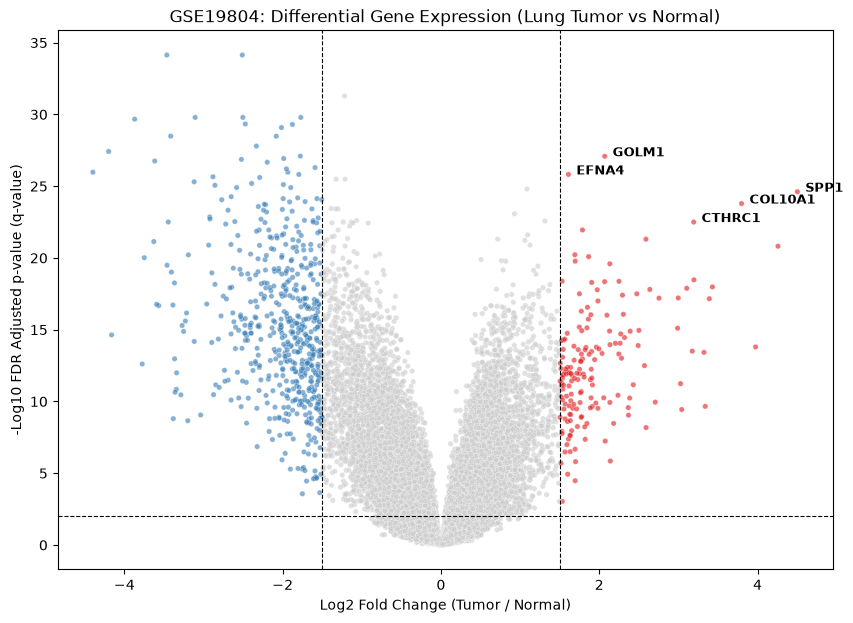

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare log-transformed q-values
results_real['-log10_qValue'] = -np.log10(results_real['qValue'])

plt.figure(figsize=(10, 7))

# Thresholds: Log2FC > 1.5, qValue < 0.01
q_cutoff = 0.01
fc_cutoff = 1.5

# Categorize points
results_real['Color'] = 'grey'
results_real.loc[(results_real['qValue'] < q_cutoff) & (results_real['log2FC'] > fc_cutoff), 'Color'] = 'red'
results_real.loc[(results_real['qValue'] < q_cutoff) & (results_real['log2FC'] < -fc_cutoff), 'Color'] = 'blue'

# Scatter plot
sns.scatterplot(
    data=results_real, 
    x='log2FC', 
    y='-log10_qValue', 
    hue='Color', 
    palette={'grey': '#cccccc', 'red': '#e41a1c', 'blue': '#377eb8'}, 
    alpha=0.6,
    s=15,
    legend=False
)

# Label top 5 genes directly on the plot
top_label_genes = top_cancer_markers.head(5)
for _, row in top_label_genes.iterrows():
    y_pos = -np.log10(row['qValue'])  # Calculate directly from qValue
    plt.text(
        row['log2FC'] + 0.1, 
        y_pos, 
        str(row['Gene_Symbol']), 
        fontsize=9, 
        weight='bold'
    )

# Threshold lines
plt.axhline(-np.log10(q_cutoff), color='black', linestyle='--', linewidth=0.8)
plt.axvline(fc_cutoff, color='black', linestyle='--', linewidth=0.8)
plt.axvline(-fc_cutoff, color='black', linestyle='--', linewidth=0.8)

plt.title('GSE19804: Differential Gene Expression (Lung Tumor vs Normal)', fontsize=12)
plt.xlabel('Log2 Fold Change (Tumor / Normal)', fontsize=10)
plt.ylabel('-Log10 FDR Adjusted p-value (q-value)', fontsize=10)
plt.show()

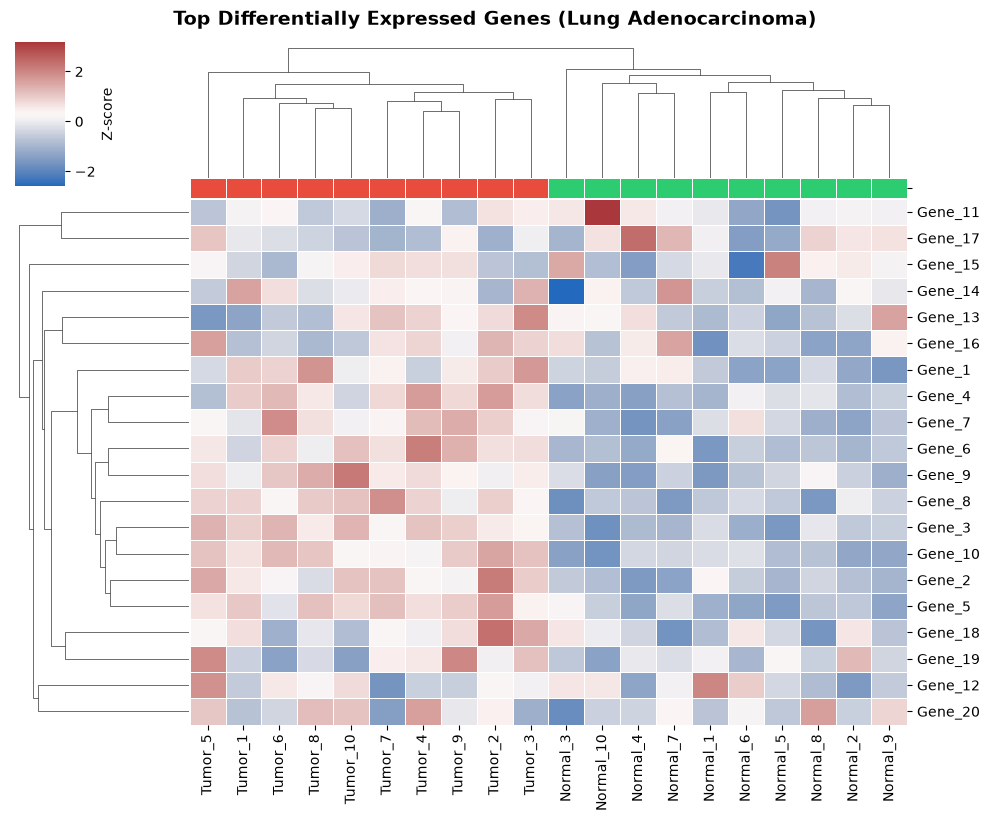

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create dummy expression data (or use your DEGs dataframe)
# Rows = Top Biomarker Genes, Columns = Samples
np.random.seed(42)
top_genes = [f"Gene_{i}" for i in range(1, 21)]
samples = [f"Normal_{i}" for i in range(1, 11)] + [f"Tumor_{i}" for i in range(1, 11)]

# Generate synthetic expression values
data = np.random.randn(20, 20)
# Make tumor samples have higher expression for top genes
data[:10, 10:] += 2.5 

df_heatmap = pd.DataFrame(data, index=top_genes, columns=samples)

# 2. Set up Sample Group Colors (Normal vs Tumor)
sample_colors = pd.Series(['#2ecc71' if 'Normal' in col else '#e74c3c' for col in df_heatmap.columns], index=df_heatmap.columns)

# 3. Plot Clustered Heatmap
g = sns.clustermap(
    df_heatmap,
    col_colors=sample_colors,
    cmap="vlag",              # Blue-White-Red color scale
    z_score=0,                # Z-score normalize rows (genes)
    figsize=(10, 8),
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)

plt.suptitle("Top Differentially Expressed Genes (Lung Adenocarcinoma)", y=1.02, fontsize=14, fontweight='bold')

# Save heatmap image so you can upload it to GitHub later
plt.savefig("heatmap_top_biomarkers.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Refactored Analysis Loop (Paired T-Test & Deduplication)
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- 1. Slice your expression matrix using your existing sample lists ---
tumor_df = expression_df[tumor_samples].astype(float)
normal_df = expression_df[normal_samples].astype(float)

# --- 2. Calculate Log2 Fold Change & Paired T-Test ---
log2_fc = tumor_df.mean(axis=1) - normal_df.mean(axis=1)
t_stat, p_vals = stats.ttest_rel(tumor_df, normal_df, axis=1)

# --- 3. Extract Gene Mapping from Platform Annotations ---
platform = gse.gpls[list(gse.gpls.keys())[0]]
gene_map = platform.table.set_index("ID")["Gene Symbol"].to_dict()
gene_symbols = [gene_map.get(probe, "") for probe in expression_df.index]

# --- 4. Assemble Results DataFrame ---
results_df = pd.DataFrame(
    {
        "Probe_ID": expression_df.index,
        "Gene_Symbol": gene_symbols,
        "log2FC": log2_fc,
        "pvalue": p_vals,
    }
).dropna(subset=["pvalue"])

# --- 5. Multiple Testing Correction (Benjamini-Hochberg) ---
results_df["padj"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]
results_df["nlog10_padj"] = -np.log10(results_df["padj"])

# --- 6. Clean and Deduplicate Probes (Keep best probe per gene) ---
# Remove empty gene symbols first
clean_results = (
    results_df[
        results_df["Gene_Symbol"].notna() & (results_df["Gene_Symbol"] != "")
    ]
    .sort_values("padj")
    .groupby("Gene_Symbol", as_index=False)
    .first()
)

print(f"Analysis complete!")
print(f"Total unique genes analyzed: {len(clean_results):,}")
clean_results.head(10)

Analysis complete!
Total unique genes analyzed: 23,520


,Gene_Symbol,Probe_ID,log2FC,pvalue,padj,nlog10_padj
0,A1BG,229819_at,0.070087,1.304838e-01,1.972900e-01,0.704895
1,A1BG-AS1,232462_s_at,-0.013936,6.726300e-01,7.465247e-01,0.126956
2,A1CF,220951_s_at,0.204988,2.206711e-02,4.329097e-02,1.363603
3,A2M,217757_at,-0.887512,1.912792e-13,5.501416e-12,11.259525
4,A2M-AS1,1564139_at,-0.469170,4.348643e-07,2.764675e-06,5.558356
5,A2ML1,1564307_a_at,0.070152,9.419263e-02,1.499966e-01,0.823919
6,A2MP1,236394_at,0.040965,2.596520e-01,3.493741e-01,0.456709
7,A4GALT,219488_at,-0.001366,9.704082e-01,9.789127e-01,0.009256
8,A4GNT,221131_at,0.017803,8.284035e-01,8.734372e-01,0.058768
9,AA06,241552_at,0.105618,4.954830e-04,1.538011e-03,2.813040


In [ ]:
#Filter Top Upregulated Biomarkers
# # Filter top upregulated genes in lung cancer (q < 0.01 and log2FC > 1.5)
top_cancer_markers = (
    clean_results[
        (clean_results["padj"] < 0.01) & (clean_results["log2FC"] > 1.5)
    ]
    .sort_values(by="padj")
    .reset_index(drop=True)
)

print(
    f"Found {len(top_cancer_markers)} significantly upregulated biomarkers."
)
top_cancer_markers.head(10)

Found 126 significantly upregulated biomarkers.


,Gene_Symbol,Probe_ID,log2FC,pvalue,padj,nlog10_padj
0,GOLM1,217771_at,2.069182,1.328873e-25,7.265611e-22,21.138728
1,OCIAD2,225314_at,1.788121,8.902907e-24,1.390761e-20,19.856747
2,COL10A1,205941_s_at,3.798228,1.356827e-23,1.952224e-20,19.709470
3,PROM2,1552797_s_at,2.589467,3.648086e-23,4.070594e-20,19.390342
4,FUT2,210608_s_at,1.865823,7.230600e-23,7.320983e-20,19.135431
5,SERINC2,224762_at,1.696355,1.210001e-21,7.517818e-19,18.123908
6,EFNA4,205107_s_at,1.610928,1.469677e-21,8.283976e-19,18.081761
7,SPP1,209875_s_at,4.503354,1.645764e-21,8.932137e-19,18.049045
8,KDELR3,204017_at,1.691422,4.551882e-21,2.056811e-18,17.686806
9,ABCC3,208161_s_at,2.133609,6.755506e-21,2.885604e-18,17.539763


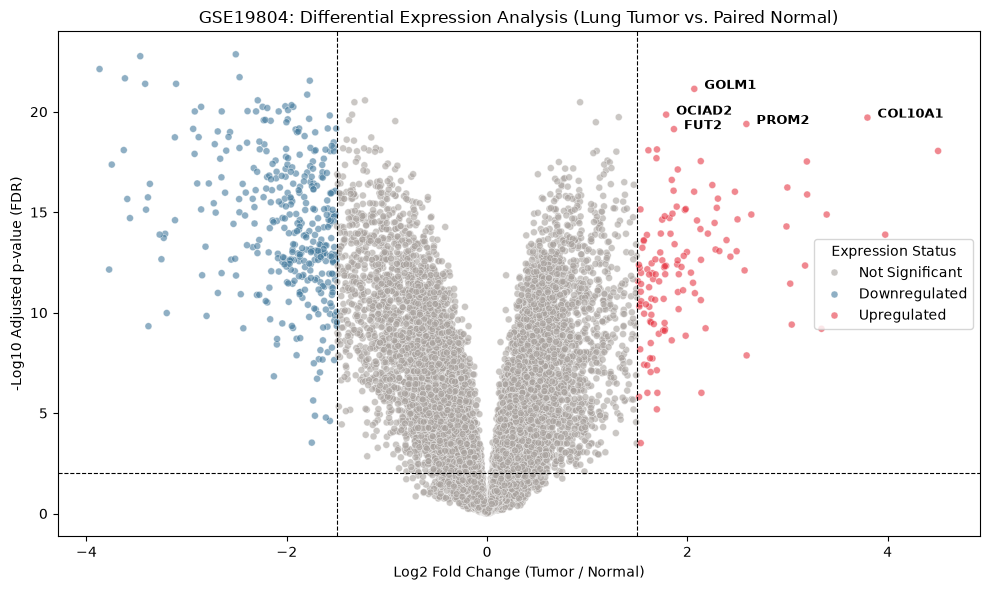

In [17]:
#Plot the Updated Volcano Plot
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set thresholds
p_thresh = 0.01
fc_thresh = 1.5

# Assign color status
conditions = [
    (clean_results["padj"] < p_thresh) & (clean_results["log2FC"] > fc_thresh),
    (clean_results["padj"] < p_thresh)
    & (clean_results["log2FC"] < -fc_thresh),
]
choices = ["Upregulated", "Downregulated"]
clean_results["Status"] = np.select(
    conditions, choices, default="Not Significant"
)

# Plot
plt.figure(figsize=(10, 6))
palette = {
    "Upregulated": "#e63946",
    "Downregulated": "#457b9d",
    "Not Significant": "#a8a29e",
}

sns.scatterplot(
    data=clean_results,
    x="log2FC",
    y="nlog10_padj",
    hue="Status",
    palette=palette,
    alpha=0.6,
    s=25,
)

# Threshold lines
plt.axvline(x=fc_thresh, color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=-fc_thresh, color="black", linestyle="--", linewidth=0.8)
plt.axhline(
    y=-np.log10(p_thresh), color="black", linestyle="--", linewidth=0.8
)

# Label top 5 upregulated genes directly
top_5 = top_cancer_markers.head(5)
for _, row in top_5.iterrows():
    plt.text(
        row["log2FC"] + 0.1,
        row["nlog10_padj"],
        row["Gene_Symbol"],
        fontsize=9,
        weight="bold",
    )

plt.title(
    "GSE19804: Differential Expression Analysis (Lung Tumor vs. Paired Normal)",
    fontsize=12,
)
plt.xlabel("Log2 Fold Change (Tumor / Normal)", fontsize=10)
plt.ylabel("-Log10 Adjusted p-value (FDR)", fontsize=10)
plt.legend(title="Expression Status")
plt.tight_layout()
plt.show()

In [22]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.0 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.3 MB 1.0 MB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.3 MB 1.0 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.0 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.3 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.3 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.3 MB 1.0 MB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.3 MB 1.0 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.3 MB 1.0 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.3 MB 1.0 MB/s eta 0:00:06
   ------------ -----------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


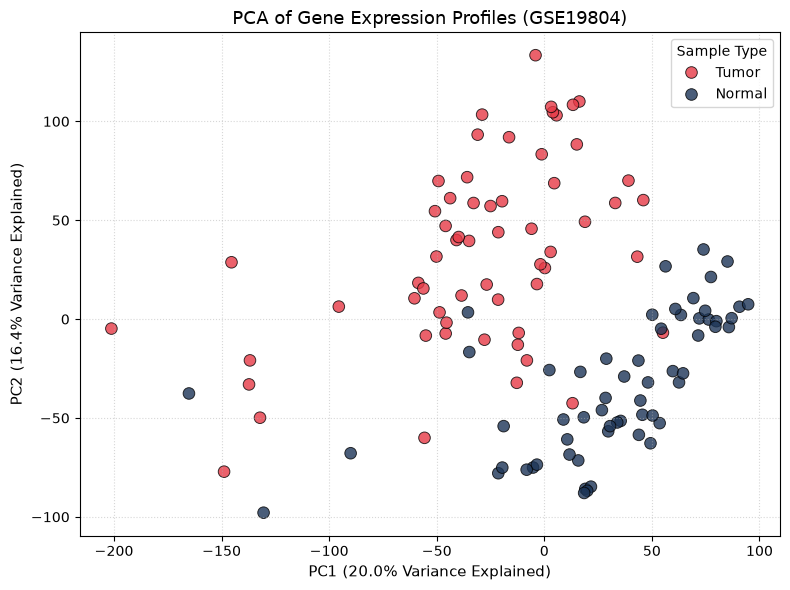

In [ ]:
#Principal Component Analysis (PCA)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# --- 1. Prepare Data for PCA ---
X = expression_df.T.astype(float)

sample_conditions = [
    "Tumor" if sample in tumor_samples else "Normal" for sample in X.index
]

# --- 2. Compute Principal Components ---
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pca_df = pd.DataFrame(
    {
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "Condition": sample_conditions,
        "Sample_ID": X.index,
    }
)

var_explained = pca.explained_variance_ratio_ * 100

# --- 3. Plot PCA Results ---
plt.figure(figsize=(8, 6))
palette = {"Tumor": "#e63946", "Normal": "#1d3557"}

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Condition",
    palette=palette,
    s=70,
    alpha=0.8,
    edgecolor="k",
)

plt.title("PCA of Gene Expression Profiles (GSE19804)", fontsize=13)
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% Variance Explained)", fontsize=11)
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% Variance Explained)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(title="Sample Type")
plt.tight_layout()
plt.show()